In [1]:
import numpy as np 
import pandas as pd
import os
from readData import *
from mgefit.mge_fit_1d import mge_fit_1d

import matplotlib.pyplot as plt

# Example Galaxy

In [2]:
galaxy = "NGC6503"

In [3]:
df, units, dist = get_rc_data(galaxy)
data, meta_units = get_mass_data(galaxy)

# MGE Fitting

Phase 1-2: SPARC surface brightness  ->  1D MGE of the disk light.
 
We fit the LIGHT (SBdisk, i.e. M/L = 1). The stellar M/L (Upsilon) is a free
MCMC parameter applied downstream as a multiplier on the Gaussian masses, so the
MGE is computed once per galaxy and never re-fit as Upsilon varies.
 
mge_fit_1d convention (verified empirically):

    p.sol[0, k] = INTEGRAL (area) of Gaussian k
    p.sol[1, k] = dispersion sigma_k   [same units as input R, i.e. kpc]
    => peak surface density  Sigma0_k = sol[0,k] / (sqrt(2*pi) * sigma_k)

In [5]:
def fit_disk_mge(R, SBdisk, ngauss=8, plot=True, name=""):
    """
    Parameters
    ----------
    R       : radii [kpc]                (from rotmod file)
    SBdisk  : disk surface brightness [Lsun/pc^2] at M/L=1  (from rotmod file)
    ngauss  : number of Gaussians
 
    Returns
    -------
    dict with:
        sigma_k  : Gaussian dispersions   [kpc]
        Sigma0_k : peak surface densities [Lsun/pc^2]  (multiply by Upsilon later)
        (mass per Gaussian at Upsilon=1, in Lsun, is  2*pi*sigma_k^2 * Sigma0_k * 1e6,
         the 1e6 converting kpc^2 -> pc^2; defer that to the potential step)
    """
    R = np.asarray(R, float)
    SB = np.asarray(SBdisk, float)
 
    # mask non-positive / non-finite SB
    m = np.isfinite(SB) & (SB > 0) & np.isfinite(R) & (R > 0)
    R, SB = R[m], SB[m]
    if R.size < ngauss + 2:
        ngauss = max(3, R.size - 2)
 
    p = mge_fit_1d(R, SB, ngauss=ngauss, plot=False, quiet=True)
    area, sigma = p.sol[0], p.sol[1]
    Sigma0 = area / (np.sqrt(2*np.pi) * sigma)          # peak surface density
 
    # ---- Checkpoint 1: reconstruct and compare ----
    def model(r):
        r = np.atleast_1d(r)[:, None]
        return (Sigma0[None, :] * np.exp(-0.5*(r/sigma[None, :])**2)).sum(1)
 
    recon = model(R)
    relerr = np.abs(recon - SB) / SB
    print(f"[{name}]  ngauss={sigma.size}  "
          f"median rel err={np.median(relerr):.2e}  max={relerr.max():.2e}")
 
    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        rr = np.linspace(R.min(), R.max(), 400)
        ax[0].plot(R, SB, 'o', ms=4, label='SBdisk (data)')
        ax[0].plot(rr, model(rr), '-', label='MGE sum')
        for s0, sg in zip(Sigma0, sigma):
            ax[0].plot(rr, s0*np.exp(-0.5*(rr/sg)**2), '--', lw=0.7, alpha=0.6)
        ax[0].set_yscale('log'); ax[0].set_xlabel('R [kpc]')
        ax[0].set_ylabel(r'$\Sigma$ [$L_\odot/pc^2$, $\Upsilon=1$]')
        ax[0].legend(fontsize=8); ax[0].set_title(f'{name}: MGE fit')
        ax[1].plot(R, 100*relerr, 'o-', ms=4)
        ax[1].set_xlabel('R [kpc]'); ax[1].set_ylabel('residual [%]')
        ax[1].axhline(0, color='k', lw=0.5); ax[1].set_title('Checkpoint 1')
        plt.tight_layout(); plt.show()
 
    return dict(sigma_k=sigma, Sigma0_k=Sigma0, name=name)

Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`
[NGC6503]  ngauss=5  median rel err=5.93e-02  max=2.47e-01


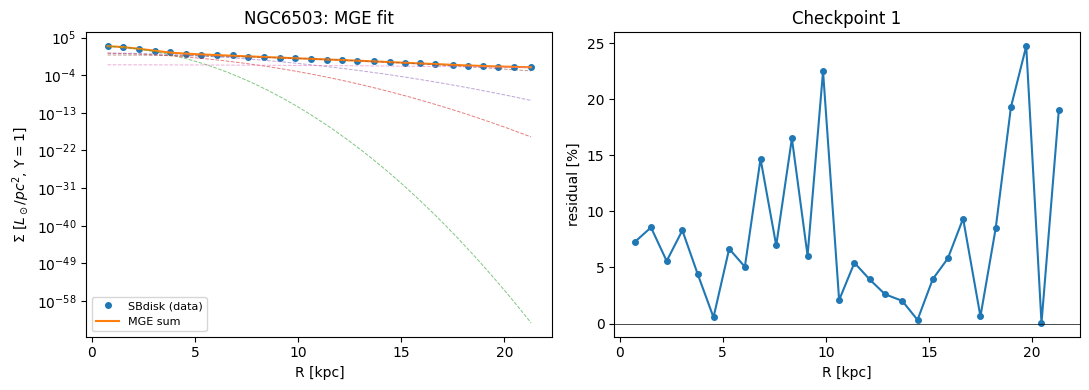

In [6]:
out = fit_disk_mge(df["Rad"].values, df["SBdisk"].values, ngauss=8, name="NGC6503")

# Deprojecting

Phase 3: deproject a 1D MGE (from Phase 2) at an intrinsic disk flattening q,
and build the axisymmetric baryonic potential Phi_b(R,z) via the Cappellari
(2008) Gaussian potential integral, plus the in-plane circular velocity.
 
Units (self-consistent):

    sigma_k  [kpc]        Gaussian dispersions
    Sigma0_k [Lsun/pc^2]  peak surface densities at Upsilon=1
    R, z     [kpc]
    Upsilon  [Msun/Lsun]  stellar mass-to-light (applied here as a multiplier)
    -> Phi in (km/s)^2,  V_c in km/s
 
Face-on projected mass per Gaussian is q-independent:  M_k = 2*pi*sigma_k^2*Sigma0_k
(with 1e6 converting kpc^2 -> pc^2), then multiplied by Upsilon.

In [7]:
G = 4.30091e-6          # kpc (km/s)^2 / Msun
 
# Gauss-Legendre nodes on [0,1] for the T-integral
_x, _w = np.polynomial.legendre.leggauss(100)
_T = 0.5*(_x + 1.0)                 # nodes  in [0,1]
_W = 0.5*_w                         # weights
 
 
def mge_component_masses(sigma_k, Sigma0_k, Upsilon=1.0):
    """Msun mass of each Gaussian (q-independent)."""
    sigma_k = np.asarray(sigma_k, float)
    Sigma0_k = np.asarray(Sigma0_k, float)
    return 2*np.pi*sigma_k**2*Sigma0_k*1e6*Upsilon      # [Msun]
 
 
def make_baryon_potential(sigma_k, Sigma0_k, q_disk, Upsilon=1.0):
    """
    Returns callables (phi, vcirc) for a single flattened MGE component.
    q_disk : intrinsic axis ratio c/a of the disk (1=sphere, ->0 razor-thin).
    """
    sigma = np.asarray(sigma_k, float)
    M = mge_component_masses(sigma, Sigma0_k, Upsilon)          # [Msun]
    q = np.full_like(sigma, float(q_disk))
    e2 = 1.0 - q**2                                             # (1-q^2) per Gaussian
 
    def phi(R, z):
        R = np.atleast_1d(np.asarray(R, float))
        z = np.atleast_1d(np.asarray(z, float))
        R, z = np.broadcast_arrays(R, z)
        out = np.zeros(R.shape)
        for k in range(sigma.size):
            denom = 1.0 - e2[k]*_T**2                           # (nq,)
            # bracket [R^2 + z^2/denom] evaluated at each node -> (..., nq)
            br = R[..., None]**2 + z[..., None]**2/denom
            integ = np.exp(-_T**2*br/(2*sigma[k]**2))/np.sqrt(denom)
            out += (M[k]/sigma[k])*(integ*_W).sum(-1)
        return -np.sqrt(2/np.pi)*G*out
 
    def vcirc(R):
        R = np.atleast_1d(np.asarray(R, float))
        v2 = np.zeros(R.shape)
        for k in range(sigma.size):
            denom = 1.0 - e2[k]*_T**2
            integ = _T**2*np.exp(-_T**2*R[..., None]**2/(2*sigma[k]**2))/np.sqrt(denom)
            v2 += (M[k]/sigma[k]**3)*R**2*(integ*_W).sum(-1)
        v2 *= np.sqrt(2/np.pi)*G
        return np.sqrt(np.clip(v2, 0, None))
 
    return phi, vcirc
 
 
def total_vcirc(components, R):
    """Quadrature-sum in-plane V_c over a list of (phi, vcirc) components."""
    return np.sqrt(sum(vc(R)**2 for _, vc in components))

In [8]:
# df, _, _ = get_rc_data("NGC6503")
# out = fit_disk_mge(df["Rad"].values, df["SBdisk"].values, ngauss=8, plot=False, name="NGC6503")

# deproject THIN to match SPARC's Vdisk convention (Upsilon=1, since Vdisk is at M/L=1)
_, vc_thin = make_baryon_potential(out["sigma_k"], out["Sigma0_k"], q_disk=0.1, Upsilon=1.0)


R = df["Rad"].values
resid = (vc_thin(R) - df["Vdisk"].values) / df["Vdisk"].values
print("Checkpoint 2  median |resid| = %.1f%%   max = %.1f%%"
      % (100*np.median(np.abs(resid)), 100*np.max(np.abs(resid))))

Checkpoint 2  median |resid| = 1.0%   max = 14.3%


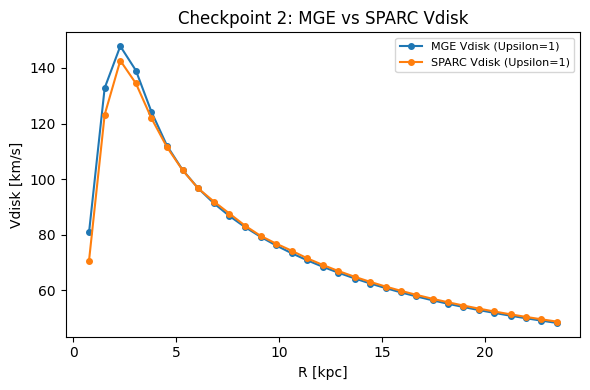

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(R, vc_thin(R), 'o-', ms=4, label='MGE Vdisk (Upsilon=1)')
plt.plot(R, df["Vdisk"].values, 'o-', ms=4, label='SPARC Vdisk (Upsilon=1)')
plt.xlabel('R [kpc]'); plt.ylabel('Vdisk [km/s]')
plt.title('Checkpoint 2: MGE vs SPARC Vdisk')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Spherical coordinates for Jeans model

In [10]:
G = 4.30091e-6          # kpc (km/s)^2 / Msun
 
# Gauss-Legendre nodes on [0,1] for the T-integral
_x, _w = np.polynomial.legendre.leggauss(100)
_T = 0.5*(_x + 1.0)                 # nodes  in [0,1]
_W = 0.5*_w                         # weights
 
 
def mge_component_masses(sigma_k, Sigma0_k, Upsilon=1.0):
    """Msun mass of each Gaussian (q-independent)."""
    sigma_k = np.asarray(sigma_k, float)
    Sigma0_k = np.asarray(Sigma0_k, float)
    return 2*np.pi*sigma_k**2*Sigma0_k*1e6*Upsilon      # [Msun]
 
 
def make_baryon_potential(sigma_k, Sigma0_k, q_disk, Upsilon=1.0):
    """
    Returns callables (phi, vcirc) for a single flattened MGE component.
    q_disk : intrinsic axis ratio c/a of the disk (1=sphere, ->0 razor-thin).
    """
    sigma = np.asarray(sigma_k, float)
    M = mge_component_masses(sigma, Sigma0_k, Upsilon)          # [Msun]
    q = np.full_like(sigma, float(q_disk))
    e2 = 1.0 - q**2                                             # (1-q^2) per Gaussian
 
    def phi(R, z):
        R = np.atleast_1d(np.asarray(R, float))
        z = np.atleast_1d(np.asarray(z, float))
        R, z = np.broadcast_arrays(R, z)
        out = np.zeros(R.shape)
        for k in range(sigma.size):
            denom = 1.0 - e2[k]*_T**2                           # (nq,)
            # bracket [R^2 + z^2/denom] evaluated at each node -> (..., nq)
            br = R[..., None]**2 + z[..., None]**2/denom
            integ = np.exp(-_T**2*br/(2*sigma[k]**2))/np.sqrt(denom)
            out += (M[k]/sigma[k])*(integ*_W).sum(-1)
        return -np.sqrt(2/np.pi)*G*out
 
    def vcirc(R):
        R = np.atleast_1d(np.asarray(R, float))
        v2 = np.zeros(R.shape)
        for k in range(sigma.size):
            denom = 1.0 - e2[k]*_T**2
            integ = _T**2*np.exp(-_T**2*R[..., None]**2/(2*sigma[k]**2))/np.sqrt(denom)
            v2 += (M[k]/sigma[k]**3)*R**2*(integ*_W).sum(-1)
        v2 *= np.sqrt(2/np.pi)*G
        return np.sqrt(np.clip(v2, 0, None))
 
    return phi, vcirc
 
 
def total_vcirc(components, R):
    """Quadrature-sum in-plane V_c over a list of (phi, vcirc) components."""
    return np.sqrt(sum(vc(R)**2 for _, vc in components))
 
 
# ----------------------------------------------------------------------
# (r, theta) interface for the Jeans model.
# theta is the polar angle from the z-axis:  R = r sin(theta),  z = r cos(theta).
# Matches the signature style of the analytic (Kuzmin/Hernquist) potentials.
# ----------------------------------------------------------------------
def mge_potential_rtheta(sigma_k, Sigma0_k, q_disk=1.0, Upsilon=1.0):
    """
    Build Phi(r, theta) for one flattened MGE component (e.g. the disk).
    q_disk=1 -> spherical; q_disk->0 -> razor-thin.  Drop-in for the Jeans model.
    """
    phi_cyl, _ = make_baryon_potential(sigma_k, Sigma0_k, q_disk, Upsilon)
 
    def func(r, th):
        scalar = np.isscalar(r) and np.isscalar(th)
        r = np.asarray(r, float); th = np.asarray(th, float)
        val = phi_cyl(r*np.sin(th), r*np.cos(th))
        return float(np.squeeze(val)) if scalar else val
    return func
 
 
def total_baryon_potential_rtheta(components):
    """
    Sum several components into a single Phi(r, theta).
    `components` is a list of dicts, each:
        {sigma_k, Sigma0_k, q, Upsilon}
    e.g. disk (flattened, Upsilon_disk) + bulge (round q~0.8, Upsilon_bul).
 
    For an MCMC where the Upsilons vary, build the per-component callables once
    at Upsilon=1 and pass fresh Upsilons here each step -- Phi scales linearly, so
    no MGE re-fit or re-integration of the fixed-q part is needed.
    """
    funcs = [mge_potential_rtheta(c["sigma_k"], c["Sigma0_k"],
                                  c.get("q", 1.0), c.get("Upsilon", 1.0))
             for c in components]
 
    def func(r, th):
        return sum(f(r, th) for f in funcs)
    return func

In [11]:
# build the baryon potential at a chosen flattening -> hand straight to the Jeans model
phi_bar = mge_potential_rtheta(out["sigma_k"], out["Sigma0_k"], q_disk=0.1, Upsilon=0.5)

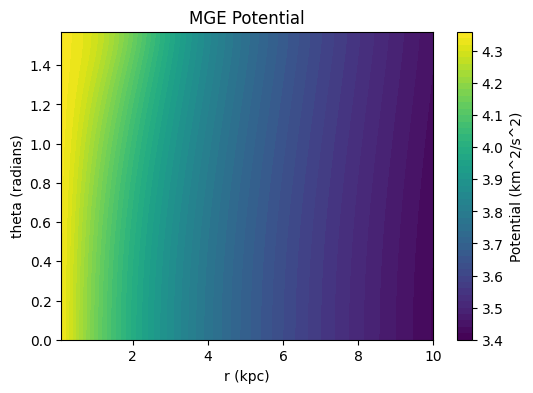

In [12]:
r_list = np.linspace(0.1, 10, 100)
thetas = np.linspace(0, np.pi/2, 100)

rs, ths = np.meshgrid(r_list, thetas, indexing='ij')

phi = phi_bar(rs, ths)

plt.figure(figsize=(6,4))
plt.contourf(rs, ths, np.log10(np.abs(phi)), levels=50, cmap='viridis')
plt.colorbar(label='Potential (km^2/s^2)')
plt.xlabel('r (kpc)')
plt.ylabel('theta (radians)')
plt.title(f'MGE Potential')
plt.show()
plt.close()

# Test MGE potential for difference q_baryon values

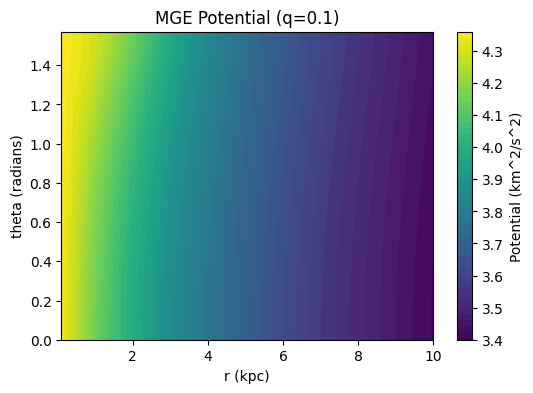

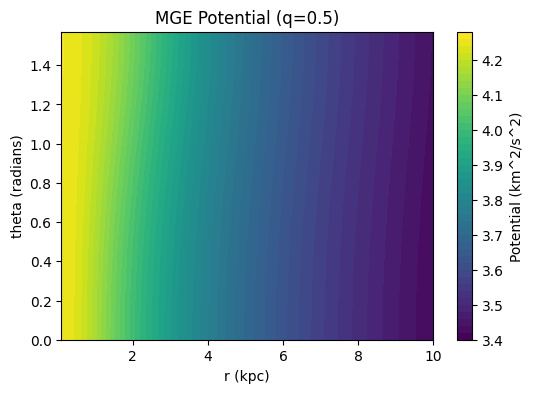

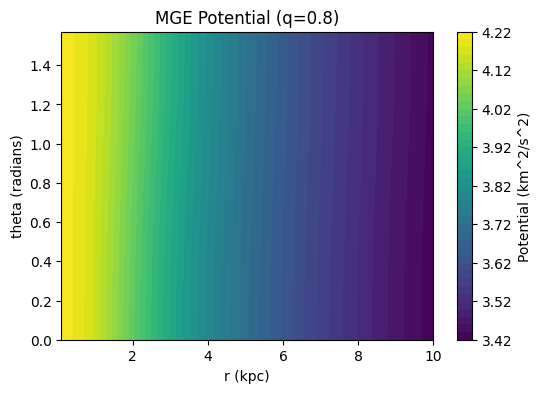

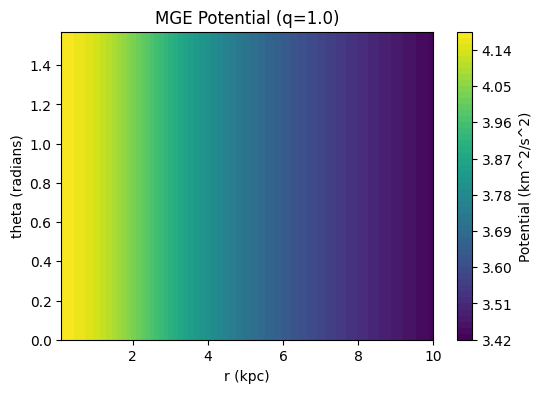

In [13]:
q_list = [0.1, 0.5, 0.8, 1.0]
r_list = np.linspace(0.1, 10, 100)
thetas = np.linspace(0, np.pi/2, 100)

rs, ths = np.meshgrid(r_list, thetas, indexing='ij')

for q in q_list:
    phi_bar = mge_potential_rtheta(out["sigma_k"], out["Sigma0_k"], q_disk=q, Upsilon=0.5)
    phi = phi_bar(rs, ths)

    plt.figure(figsize=(6,4))
    plt.contourf(rs, ths, np.log10(np.abs(phi)), levels=50, cmap='viridis')
    plt.colorbar(label='Potential (km^2/s^2)')
    plt.xlabel('r (kpc)')
    plt.ylabel('theta (radians)')
    plt.title(f'MGE Potential (q={q})')
    plt.show()
    plt.close()

# Add the gas component

Gas component: invert SPARC's Vgas(R) into a thin-disk MGE surface density,
so it can enter Phi(r,theta) exactly like the stellar disk.
 
Why an inversion: SPARC tabulates the gas *velocity* Vgas, not a gas surface
density. For a razor-thin disk the map Vgas(R) -> Sigma_gas(R) is unique (no q
freedom), so we recover Sigma_gas by forward-modeling:
 
    V_c^2(R) is LINEAR in the Gaussian masses, so fit Sigma_gas as a
    NON-NEGATIVE sum of Gaussians whose forward thin-disk V_c matches Vgas.
    -> solved by NNLS (guarantees Sigma_gas >= 0 everywhere).
 
Notes:

  * Vgas already includes the 1.33 He/metals correction, so the recovered
    Sigma_gas is TOTAL gas.  Do NOT scale it by Upsilon: it enters at Upsilon=1.
  * The central HI hole shows up as slightly negative inner Vgas.  A sum of
    positive Gaussians cannot make a central deficit, so the hole is gently
    underfit -- harmless, since gas is sub-dominant there.
  * Deproject at a fixed thin q_gas (~0.05); gas thickness does not drive the
    DM response, so this is not a scanned parameter.


In [14]:
from scipy.optimize import nnls

Q_GAS = 0.05
 
def invert_vgas_to_mge(R, Vgas, ngauss=12, q_gas=Q_GAS, plot=True, name="",
                       Vdisk_ref=None, Upsilon_ref=0.5):
    """
    Returns dict(sigma_k [kpc], Sigma0_k [Msun/pc^2]) describing the gas MGE.
    Feed straight into total_baryon_potential_rtheta with q=q_gas, Upsilon=1.
 
    If Vdisk_ref (the stellar Vdisk column) is supplied, the checkpoint also
    reports the impact of any gas misfit on the TOTAL baryonic curve Vbar --
    the number that actually matters, since the gas adds in quadrature with the
    (usually dominant) stars.
    """
    R = np.asarray(R, float)
    Vgas = np.asarray(Vgas, float)
    m = np.isfinite(R) & np.isfinite(Vgas) & (R > 0)
    R, Vgas = R[m], Vgas[m]
 
    # signed square preserves the sign of the central-hole region
    target = Vgas*np.abs(Vgas)                       # (km/s)^2
 
    # log-spaced basis widths spanning the sampled range
    dR = np.median(np.diff(np.sort(R)))
    sig = np.geomspace(max(0.5*dR, 0.3), R.max(), ngauss)
 
    # kernel: forward V_c^2(R_i) for a unit-peak (Sigma0=1) Gaussian of width sig_k
    K = np.empty((R.size, ngauss))
    for k in range(ngauss):
        _, vck = make_baryon_potential([sig[k]], [1.0], q_disk=q_gas, Upsilon=1.0)
        K[:, k] = vck(R)**2
 
    # fractional weighting so the extended outer disk isn't swamped by big numbers
    w = 1.0/np.sqrt(np.abs(target) + 25.0)           # floor ~ (5 km/s)^2
    Sigma0, _ = nnls(K*w[:, None], target*w)         # Sigma0_k >= 0  [Msun/pc^2]
 
    keep = Sigma0 > 0
    sig, Sigma0 = sig[keep], Sigma0[keep]
 
    # ---- checkpoint: forward V_c of the recovered gas MGE vs Vgas ----
    _, vc = make_baryon_potential(sig, Sigma0, q_disk=q_gas, Upsilon=1.0)
    vmod = vc(R)
    outer = R > 0.15*R.max()                          # judge where gas matters
    resid = vmod[outer] - np.abs(Vgas)[outer]
    print(f"[{name}] gas inversion: {sig.size} Gaussians  "
          f"outer-disk V_c residual: median {np.median(np.abs(resid)):.2f} km/s  "
          f"max {np.max(np.abs(resid)):.2f} km/s")
 
    if Vdisk_ref is not None:
        Vd = np.asarray(Vdisk_ref, float)[m]
        Vbar_model = np.sqrt(np.clip(Upsilon_ref*Vd**2 + vmod**2, 0, None))
        Vbar_true = np.sqrt(np.clip(Upsilon_ref*Vd**2 + Vgas*np.abs(Vgas), 0, None))
        dV = np.abs(Vbar_model - Vbar_true)
        print(f"           -> impact on TOTAL Vbar (Upsilon_d={Upsilon_ref}): "
              f"median {np.median(dV):.2f}  max {np.max(dV):.2f} km/s "
              f"(cf. Vobs errors ~2-5 km/s)")
 
    if plot:
        import matplotlib.pyplot as plt
        rr = np.linspace(R.min(), R.max(), 400)
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        ax[0].plot(R, np.abs(Vgas), 'o', ms=4, label='|Vgas| (SPARC)')
        ax[0].plot(rr, vc(rr), '-', label='forward V_c of gas MGE')
        ax[0].set_xlabel('R [kpc]'); ax[0].set_ylabel('V_gas [km/s]')
        ax[0].legend(fontsize=8); ax[0].set_title(f'{name}: gas inversion check')
        Sig = lambda r: (Sigma0[None, :]*np.exp(-0.5*(r[:, None]/sig[None, :])**2)).sum(1)
        ax[1].plot(rr, Sig(rr), '-')
        ax[1].set_yscale('log'); ax[1].set_xlabel('R [kpc]')
        ax[1].set_ylabel(r'$\Sigma_{gas}$ [$M_\odot/pc^2$]')
        ax[1].set_title('recovered gas surface density')
        plt.tight_layout(); plt.show()
 
    return dict(sigma_k=sig, Sigma0_k=Sigma0, q_gas=q_gas)

[galaxy] gas inversion: 4 Gaussians  outer-disk V_c residual: median 0.31 km/s  max 0.88 km/s


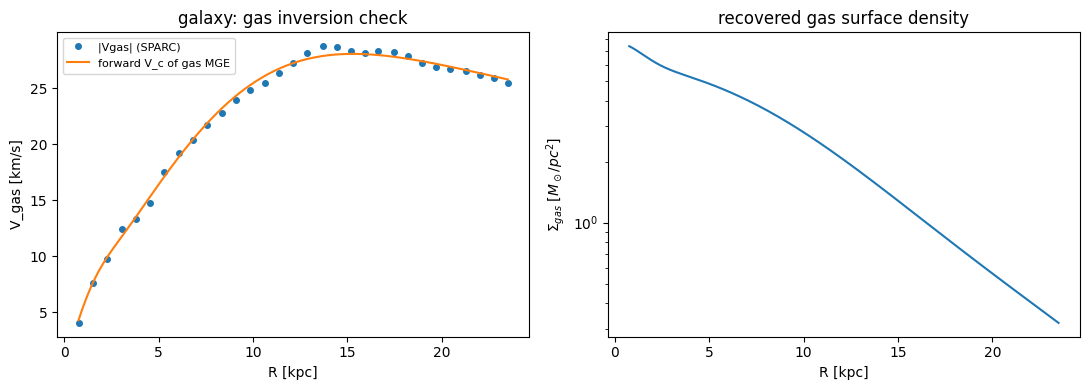

sigma_k [kpc]: [ 1.22  2.21  7.2  13.01]
Sigma0_k     : [1.639 0.25  4.324 1.529]


In [15]:
out = invert_vgas_to_mge(df["Rad"], df["Vgas"], ngauss=8, plot=True, name="galaxy")
print("sigma_k [kpc]:", np.array2string(out["sigma_k"], precision=2))
print("Sigma0_k     :", np.array2string(out["Sigma0_k"], precision=3))

In [16]:
disk = fit_disk_mge(df["Rad"].values, df["SBdisk"].values, ngauss=8, plot=False)
gas  = invert_vgas_to_mge(df["Rad"].values, df["Vgas"].values, ngauss=8, plot=False,
                          Vdisk_ref=df["Vdisk"].values)   # Vdisk_ref -> Vbar-impact readout

# full baryonic potential, disk flattening scanned, gas fixed-thin, gas never scaled by Upsilon
phi_bar = total_baryon_potential_rtheta([
    dict(sigma_k=disk["sigma_k"], Sigma0_k=disk["Sigma0_k"], q=0.1, Upsilon=1.0),
    dict(sigma_k=gas["sigma_k"],  Sigma0_k=gas["Sigma0_k"],  q=0.05,   Upsilon=1.0),
])

Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`
[]  ngauss=5  median rel err=5.93e-02  max=2.47e-01
[] gas inversion: 4 Gaussians  outer-disk V_c residual: median 0.31 km/s  max 0.88 km/s
           -> impact on TOTAL Vbar (Upsilon_d=0.5): median 0.11  max 0.46 km/s (cf. Vobs errors ~2-5 km/s)


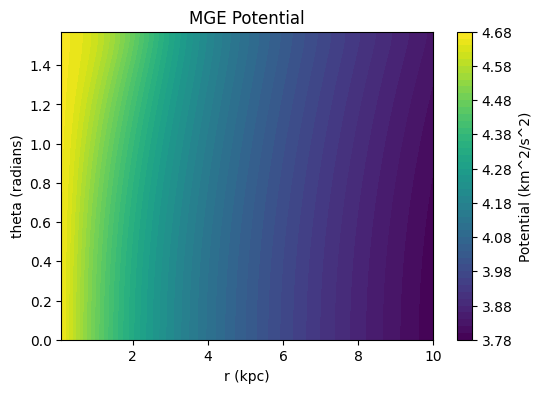

In [17]:
r_list = np.linspace(0.1, 10, 100)
thetas = np.linspace(0, np.pi/2, 100)

rs, ths = np.meshgrid(r_list, thetas, indexing='ij')

phi = phi_bar(rs, ths)

plt.figure(figsize=(6,4))
plt.contourf(rs, ths, np.log10(np.abs(phi)), levels=50, cmap='viridis')
plt.colorbar(label='Potential (km^2/s^2)')
plt.xlabel('r (kpc)')
plt.ylabel('theta (radians)')
plt.title(f'MGE Potential')
plt.show()
plt.close()

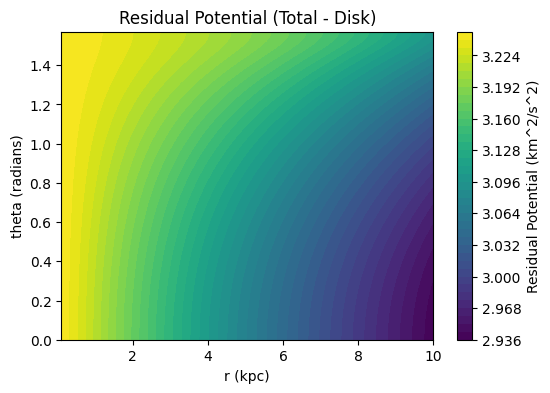

In [18]:
phi_bar_d = total_baryon_potential_rtheta([
    dict(sigma_k=disk["sigma_k"], Sigma0_k=disk["Sigma0_k"], q=0.1, Upsilon=1.0)
])

phi_bar_t = total_baryon_potential_rtheta([
    dict(sigma_k=disk["sigma_k"], Sigma0_k=disk["Sigma0_k"], q=0.1, Upsilon=1.0),
    dict(sigma_k=gas["sigma_k"],  Sigma0_k=gas["Sigma0_k"],  q=0.05,   Upsilon=1.0),
])

r_list = np.linspace(0.1, 10, 100)
thetas = np.linspace(0, np.pi/2, 100)

rs, ths = np.meshgrid(r_list, thetas, indexing='ij')

phid = phi_bar_d(rs, ths)
phit = phi_bar_t(rs, ths)

residual = phit - phid

plt.figure(figsize=(6,4))
plt.contourf(rs, ths, np.log10(np.abs(residual)), levels=50, cmap='viridis')
plt.colorbar(label='Residual Potential (km^2/s^2)')
plt.xlabel('r (kpc)')
plt.ylabel('theta (radians)')
plt.title(f'Residual Potential (Total - Disk)')
plt.show()

# Add the bulge componenet

In [30]:
df, _, _ = get_rc_data("NGC6674")
# df

In [32]:
df.columns

Index(['Rad', 'Vobs', 'errV', 'Vgas', 'Vdisk', 'Vbul', 'SBdisk', 'SBbul'], dtype='object')

If the bulge has no SBbulge or only one value -> Use the same gas inversion

In [28]:
def invert_vcirc_to_mge(R, Vc, q, ngauss=12, sig_min=0.5, sig_max=None,
                        signed=False, weight_floor=10.0, plot=False, name=""):
    """
    Returns dict(sigma_k [kpc], Sigma0_k [Msun/pc^2], q, M_tot [Msun]).
    Feed into total_baryon_potential_rtheta with the returned q.
 
    signed : if True, fit Vc*|Vc| (preserves sign of a central hole, for gas).
             if False, fit Vc**2 (for the strictly-positive bulge).
    """
    R = np.asarray(R, float); Vc = np.asarray(Vc, float)
    m = np.isfinite(R) & np.isfinite(Vc) & (R > 0)
    R, Vc = R[m], Vc[m]
    if sig_max is None:
        sig_max = R.max()/3.0
 
    target = Vc*np.abs(Vc) if signed else Vc**2
    sig = np.geomspace(sig_min, sig_max, ngauss)
 
    K = np.empty((R.size, ngauss))
    for k in range(ngauss):
        _, vck = make_baryon_potential([sig[k]], [1.0], q_disk=q, Upsilon=1.0)
        K[:, k] = vck(R)**2
 
    w = 1.0/(2*(np.abs(Vc) + weight_floor))         # ~velocity-space residual
    Sigma0, _ = nnls(K*w[:, None], target*w)
    keep = Sigma0 > 0
    sig, Sigma0 = sig[keep], Sigma0[keep]
 
    _, vc = make_baryon_potential(sig, Sigma0, q_disk=q, Upsilon=1.0)
    resid = vc(R) - np.abs(Vc)
    Mtot = mge_component_masses(sig, Sigma0).sum()
    print(f"[{name}] inversion (q={q}): {sig.size} Gaussians, M_tot(Ups=1)={Mtot:.3e} Msun | "
          f"Vc recovery median {np.median(np.abs(resid)):.2f}  max {np.max(np.abs(resid)):.2f} km/s")
 
    if plot:
        import matplotlib.pyplot as plt
        rr = np.linspace(R.min(), R.max(), 400)
        plt.figure(figsize=(6,4))
        plt.plot(R, np.abs(Vc), 'o', label=f'|Vc| SPARC ({name})')
        plt.plot(rr, vc(rr), '-', label='forward V_c of MGE')
        plt.xlabel('R [kpc]'); plt.ylabel('V [km/s]'); plt.legend(); plt.title(name)
        plt.tight_layout(); plt.show()
 
    return dict(sigma_k=sig, Sigma0_k=Sigma0, q=q, M_tot=Mtot)

[NGC6674 bulge] inversion (q=0.8): 7 Gaussians, M_tot(Ups=1)=1.725e+10 Msun | Vc recovery median 0.00  max 0.00 km/s


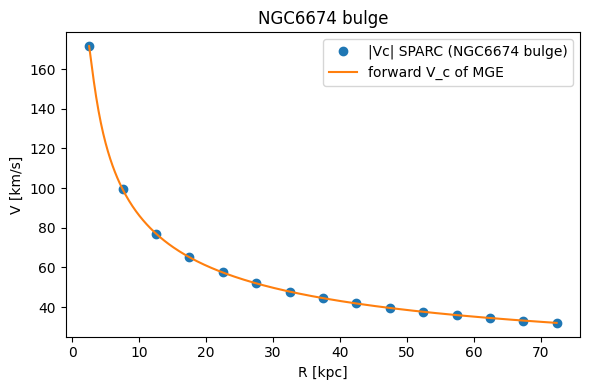

In [33]:
bulge = invert_vcirc_to_mge(df["Rad"], df["Vbul"], q=0.8, sig_min=0.5, signed=False, name="NGC6674 bulge", plot=True)

Usable SBbul

In [35]:
df, _, _ = get_rc_data("NGC2841")
# df

Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`
[NGC2841]  ngauss=1  median rel err=8.25e-01  max=9.90e-01


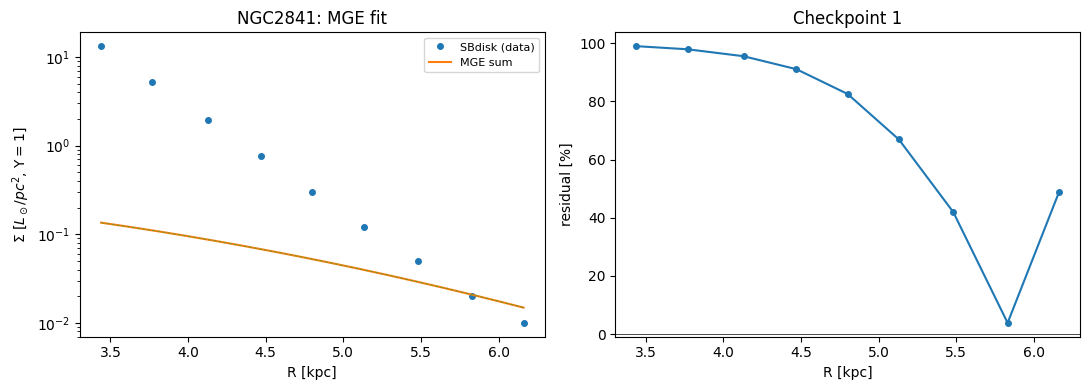

Checkpoint 2  median |resid| = 99.0%   max = 99.1%


In [39]:
out = fit_disk_mge(df["Rad"].values, df["SBbul"].values, ngauss=12, name="NGC2841")
_, vc_thin = make_baryon_potential(out["sigma_k"], out["Sigma0_k"], q_disk=0.8, Upsilon=1.0)


R = df["Rad"].values
resid = (vc_thin(R) - df["Vdisk"].values) / df["Vdisk"].values
print("Checkpoint 2  median |resid| = %.1f%%   max = %.1f%%"
      % (100*np.median(np.abs(resid)), 100*np.max(np.abs(resid))))

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(R, vc_thin(R), 'o-', ms=4, label='MGE Vdisk (Upsilon=1)')
plt.plot(R, df["Vbul"].values, 'o-', ms=4, label='SPARC Vbul (Upsilon=1)')
plt.xlabel('R [kpc]'); plt.ylabel('Vbul [km/s]')
plt.title('Checkpoint 2: MGE vs SPARC Vbul')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

# Test mge_potential script

In [2]:
from mge_potential import BaryonicModel

Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`
[NGC6674] SB-MGE: 4 Gaussians  median rel err 2.50e-02
BaryonicModel(NGC6674, qdisk=0.15, qbul=0.8, qgas=0.05 | d:SBdisk-MGE, b:Vbul-inversion (point mass), g:Vgas-inversion)


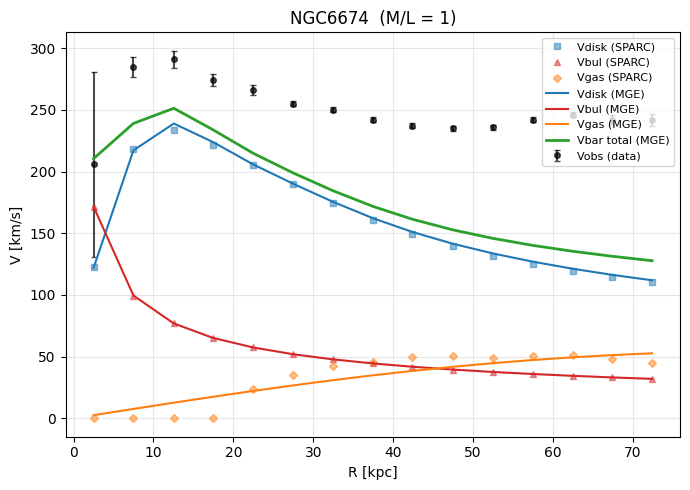

In [3]:
galaxy = "NGC6674"
bar = BaryonicModel(galaxy, qdisk=0.15, ngauss=6, verbose=True)     # fits disk+bulge+gas once
print(bar)                                   # shows which route each component took

# SPARC's Vdisk/Vbul columns are tabulated at M/L=1, so compare the model at Upsilon=1
cur = bar.model_curves(Upsilond=1.0, Upsilonb=1.0)
R = cur["R"]
df = bar.data                                # same data the class loaded

plt.figure(figsize=(7,5))
# --- data points (SPARC), M/L=1 components ---
plt.errorbar(df["Rad"], df["Vobs"], yerr=df["errV"], fmt='o', ms=4, color='k',
             capsize=2, alpha=0.7, label='Vobs (data)')
plt.plot(df["Rad"], df["Vdisk"], 's', ms=4, color='C0', alpha=0.5, label='Vdisk (SPARC)')
plt.plot(df["Rad"], df["Vbul"],  '^', ms=4, color='C3', alpha=0.5, label='Vbul (SPARC)')
plt.plot(df["Rad"], np.abs(df["Vgas"]), 'D', ms=4, color='C1', alpha=0.5, label='Vgas (SPARC)')

# --- model curves (lines) ---
plt.plot(R, cur["Vdisk"], '-', color='C0', label='Vdisk (MGE)')
plt.plot(R, cur["Vbul"],  '-', color='C3', label='Vbul (MGE)')
plt.plot(R, cur["Vgas"],  '-', color='C1', label='Vgas (MGE)')
plt.plot(R, cur["Vbar"],  '-', color='C2', lw=2, label='Vbar total (MGE)')

plt.xlabel('R [kpc]'); plt.ylabel('V [km/s]')
plt.title(f'{galaxy}  (M/L = 1)'); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

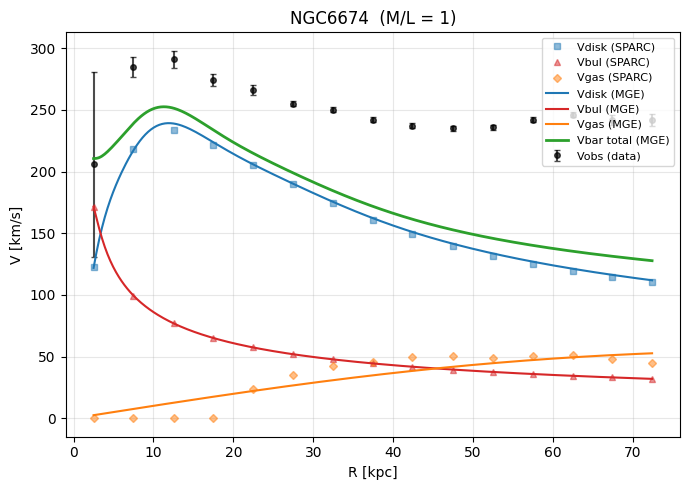

In [7]:
R_fine = np.linspace(bar.R.min(), bar.R.max(), 400)
cur = bar.model_curves(Upsilond=1.0, Upsilonb=1.0, R=R_fine, D=bar.dist)   # smooth lines
df  = bar.data

plt.figure(figsize=(7,5))
# data markers at the real radii
plt.errorbar(df["Rad"], df["Vobs"], yerr=df["errV"], fmt='o', ms=4, color='k',
             capsize=2, alpha=0.7, label='Vobs (data)')
plt.plot(df["Rad"], df["Vdisk"], 's', ms=4, color='C0', alpha=0.5, label='Vdisk (SPARC)')
plt.plot(df["Rad"], df["Vbul"],  '^', ms=4, color='C3', alpha=0.5, label='Vbul (SPARC)')
plt.plot(df["Rad"], np.abs(df["Vgas"]), 'D', ms=4, color='C1', alpha=0.5, label='Vgas (SPARC)')

# model lines on the fine grid
plt.plot(R_fine, cur["Vdisk"], '-', color='C0', label='Vdisk (MGE)')
plt.plot(R_fine, cur["Vbul"],  '-', color='C3', label='Vbul (MGE)')
plt.plot(R_fine, cur["Vgas"],  '-', color='C1', label='Vgas (MGE)')
plt.plot(R_fine, cur["Vbar"],  '-', color='C2', lw=2, label='Vbar total (MGE)')

plt.xlabel('R [kpc]'); plt.ylabel('V [km/s]')
plt.title(f'{galaxy}  (M/L = 1)'); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# MGE Potential

NB: Ask how i and D are used in the potential file

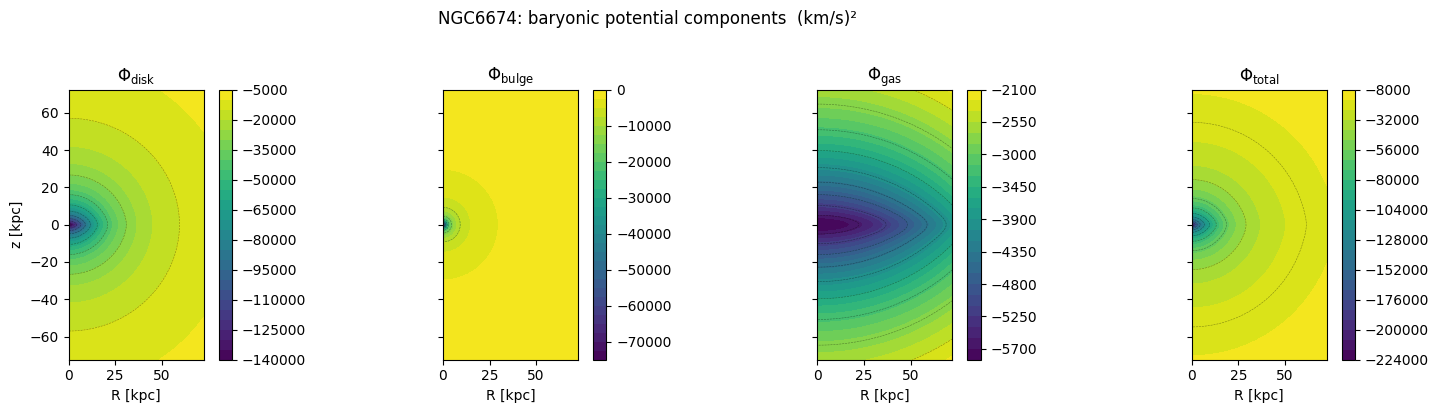

In [5]:
Yd, Yb = 1.0, 1.0                    # M/L's (1.0 for a bare-potential test)
scale = {"d": Yd, "b": Yb, "g": 1.0} # gas never scaled
names = {"d": "disk", "b": "bulge", "g": "gas"}

# meridional (R, z) grid
Rmax = bar.R.max()
RR, ZZ = np.meshgrid(np.linspace(0, Rmax, 200),
                     np.linspace(-Rmax, Rmax, 200))

# evaluate each component (Upsilon-scaled) and the total
comp = {}
total = np.zeros_like(RR)
for c in bar.components:
    phi = scale[c["tag"]] * c["phi"](RR, ZZ)
    comp[names[c["tag"]]] = phi
    total += phi

panels = list(comp.items()) + [("total", total)]
fig, axes = plt.subplots(1, len(panels), figsize=(4*len(panels), 4), sharey=True)
for ax, (label, phi) in zip(axes, panels):
    cf = ax.contourf(RR, ZZ, phi, levels=30, cmap="viridis")
    ax.contour(RR, ZZ, phi, levels=10, colors="k", linewidths=0.4, alpha=0.4)
    ax.set_title(rf"$\Phi_\mathrm{{{label}}}$")
    ax.set_xlabel("R [kpc]"); ax.set_aspect("equal")
    fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
axes[0].set_ylabel("z [kpc]")
fig.suptitle(f"{bar.galaxy}: baryonic potential components  (km/s)²", y=1.02)
plt.tight_layout(); plt.show()

/tmp/ipykernel_116562/1915570297.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax[0].pcolormesh(R, z, np.log(-Phi), shading="auto", cmap="viridis")


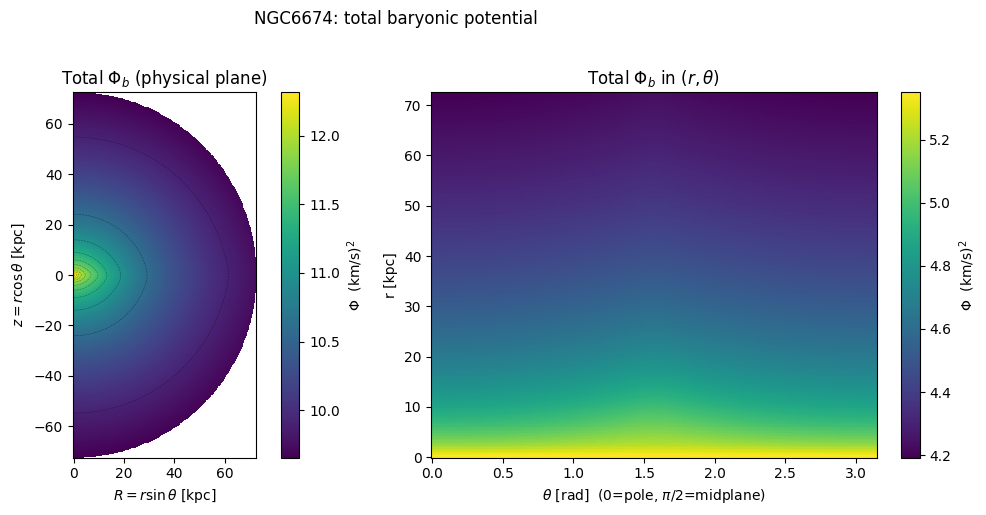

In [7]:
Yd, Yb = 1.0, 1.0

rmax = bar.R.max()
r  = np.linspace(0.05, rmax, 250)
th = np.linspace(0, np.pi, 250)          # 0 = +z pole, π/2 = midplane, π = -z pole
RG, TH = np.meshgrid(r, th)

# evaluate the TOTAL through the (r, θ) interface — the exact call the Jeans model makes
Phi = bar.potential(RG, TH, Yd, Yb)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# (a) physical meridional view: map (r,θ) -> (R,z) for legibility
R, z = RG*np.sin(TH), RG*np.cos(TH)
pcm = ax[0].pcolormesh(R, z, np.log(-Phi), shading="auto", cmap="viridis")
ax[0].contour(R, z, Phi, levels=12, colors="k", linewidths=0.4, alpha=0.4)
ax[0].set_xlabel(r"$R = r\sin\theta$ [kpc]"); ax[0].set_ylabel(r"$z = r\cos\theta$ [kpc]")
ax[0].set_aspect("equal"); ax[0].set_title(r"Total $\Phi_b$ (physical plane)")
fig.colorbar(pcm, ax=ax[0], fraction=0.046, label=r"$\Phi$  (km/s)$^2$")

# (b) literal (r, θ) axes
pcm2 = ax[1].pcolormesh(TH, RG, np.log10(-Phi), shading="auto", cmap="viridis")
ax[1].set_xlabel(r"$\theta$ [rad]  (0=pole, $\pi/2$=midplane)"); ax[1].set_ylabel("r [kpc]")
ax[1].set_title(r"Total $\Phi_b$ in $(r,\theta)$")
fig.colorbar(pcm2, ax=ax[1], fraction=0.046, label=r"$\Phi$  (km/s)$^2$")

fig.suptitle(f"{bar.galaxy}: total baryonic potential", y=1.02)
plt.tight_layout(); plt.show()

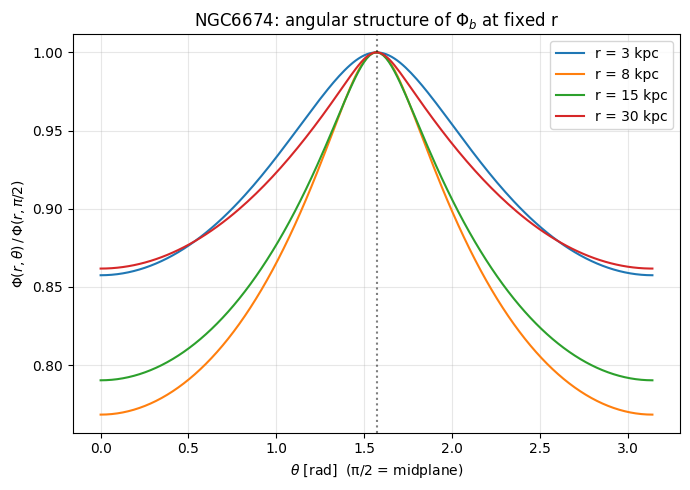

In [8]:
th = np.linspace(0, np.pi, 200)
plt.figure(figsize=(7,5))
for r0 in [3, 8, 15, 30]:
    phi = bar.potential(r0*np.ones_like(th), th)
    plt.plot(th, phi/phi[len(th)//2], label=f"r = {r0} kpc")   # normalize to midplane
plt.axvline(np.pi/2, color='k', ls=':', alpha=0.5)
plt.xlabel(r"$\theta$ [rad]  (π/2 = midplane)")
plt.ylabel(r"$\Phi(r,\theta)\,/\,\Phi(r,\pi/2)$")
plt.title(f"{bar.galaxy}: angular structure of $\\Phi_b$ at fixed r")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`
Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`
Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`
Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`
Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`


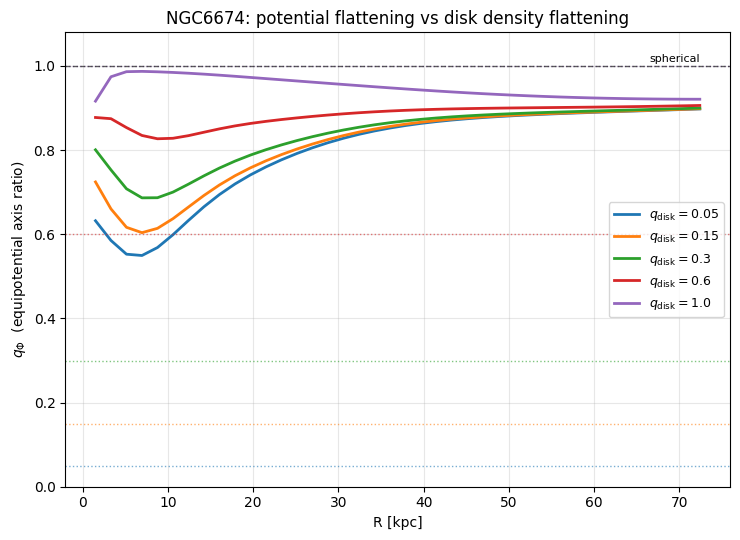

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from mge_potential import BaryonicModel

def q_potential(bar, Rp):
    """Axis ratio of the equipotential through (R=Rp, z=0):  z_axis / Rp."""
    phi0 = bar.potential(Rp, np.pi/2)
    f = lambda z: bar.potential(z, 0.0) - phi0
    try:
        return brentq(f, 1e-3, 5*Rp)/Rp
    except ValueError:
        return np.nan

Rgrid = np.linspace(1.5, bar.R.max(), 40)

plt.figure(figsize=(7.5, 5.5))
for q in [0.05, 0.15, 0.3, 0.6, 1.0]:
    m = BaryonicModel(bar.galaxy, qdisk=q)          # one model per q_disk
    qphi = np.array([q_potential(m, R) for R in Rgrid])
    line, = plt.plot(Rgrid, qphi, lw=2, label=fr"$q_\mathrm{{disk}}={q}$")
    plt.axhline(q, color=line.get_color(), ls=":", lw=1, alpha=0.6)  # density flattening

plt.axhline(1.0, color='k', ls='--', lw=1, alpha=0.6)
plt.text(Rgrid[-1], 1.005, "spherical", ha='right', va='bottom', fontsize=8)
plt.xlabel("R [kpc]")
plt.ylabel(r"$q_\Phi$  (equipotential axis ratio)")
plt.title(f"{bar.galaxy}: potential flattening vs disk density flattening")
plt.ylim(0, 1.08); plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()